# 06 · Safety

Sources: OpenStreetMap India via Geofabrik (ODbL) · MoRTH Annual Report 2024-25, Appendix-2 (as on 31.12.2024) · WorldPop 2020 1 km (CC BY 4.0) · GHSL built-up (CC BY 4.0) · MoRTH Road Accidents in India 2024 · NHAI Datalake — aggregates only (ADR-0014). Rebuild everything: `cd ml && uv run python -m fields.national_highways all`.

National 2024 totals come from Road Accidents in India 2024. State rates are Road Accidents in India 2024 Annexures 9–10 (OCR'd, checked against printed totals) over MoRTH's official NH length (31.12.2024). NHAI crash points only show where crashes cluster.

In [1]:
import json
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

ML = Path.cwd().resolve().parents[1]  # ml/notebooks/national_highways -> ml
sys.path.insert(0, str(ML))
from fields.national_highways import analysis as nh

A = nh.A
SUMMARY = json.loads((A / "summary.json").read_text())
pd.set_option("display.max_rows", 40)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.dpi": 80, "figure.figsize": (9, 4.5), "axes.spines.top": False, "axes.spines.right": False})

In [2]:
rai = SUMMARY["rai_national"]
display(pd.DataFrame(rai["nh_series"]).T.rename_axis("year"))
pd.DataFrame(rai["by_agency_2024"]).T

,accidents,deaths
year,,
2020,119615,50251
2021,128825,56007
2022,151997,61038
2023,150177,63112
2024,150958,64772


,accidents,deaths
nhai,108240,49675
state_pwd,35118,11998
other,7600,3099


,accidents,deaths,official_km,deaths_per_100km,deaths_change_since_first_year,nhai_layer_crashes_2022_23
state,,,,,,
Delhi,593.00,258.00,157.00,164.33,0.28,483.00
Puducherry,631.00,105.00,64.00,164.06,0.21,1.00
Tamil Nadu,"20,672.00","6,376.00","7,000.00",91.09,0.21,"12,448.00"
Uttar Pradesh,"17,113.00","9,560.00","12,123.00",78.86,0.12,"11,583.00"
Bihar,"4,681.00","4,012.00","6,132.00",65.43,0.14,"1,444.00"
Telangana,"8,599.00","3,066.00","4,926.00",62.24,0.12,"4,688.00"
Haryana,"3,844.00","2,052.00","3,347.00",61.31,0.16,"3,843.00"
West Bengal,"4,172.00","2,113.00","3,910.00",54.04,-0.03,"2,319.00"
Chhattisgarh,"4,156.00","1,952.00","3,620.00",53.92,0.17,790.00


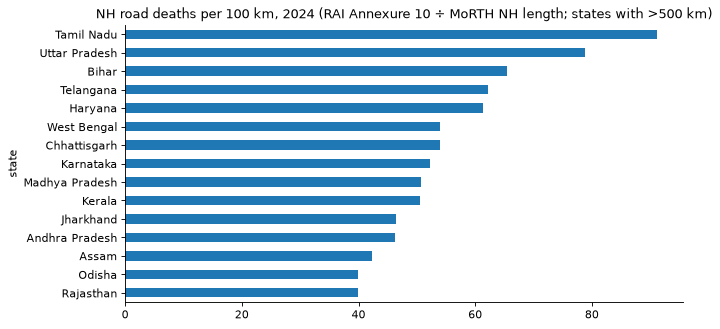

In [3]:
saf = pd.read_csv(A / "safety_by_state.csv", index_col=0)
big = saf[(saf.index != "India") & (saf.official_km > 500)]
big.sort_values("deaths_per_100km").tail(15).plot.barh(y="deaths_per_100km", legend=False, title="NH road deaths per 100 km, 2024 (RAI Annexure 10 ÷ MoRTH NH length; states with >500 km)");
saf.round(2)

## How complete is NHAI's crash layer?

In [4]:
cr = gpd.read_parquet(nh.OUT / "nhai_crashes.parquet")
yearly = cr.groupby(cr.date.dt.year).size()
display(yearly)
nhai = SUMMARY["rai_national"]["by_agency_2024"]["nhai"]
deaths = cr.groupby(cr.date.dt.year).deaths.sum()
print(f"2023 layer: {yearly[2023]:,} crashes = {yearly[2023] / nhai['accidents']:.0%} of the {nhai['accidents']:,} accidents RAI 2024 reports on NHAI roads; "
      f"{deaths[2023]:,.0f} deaths = {deaths[2023] / nhai['deaths']:.0%} of {nhai['deaths']:,}")

date
2020     1784
2021      775
2022    38957
2023    49992
dtype: int64

2023 layer: 49,992 crashes = 46% of the 108,240 accidents RAI 2024 reports on NHAI roads; 6,274 deaths = 13% of 49,675


## Crashes by lane band
Per km, not per vehicle-km: wider roads carry far more traffic, and the layer covers NHAI-run corridors best. Read it as where crashes concentrate, not as the risk of a trip.

In [5]:
band = pd.read_csv(A / "crash_rate_by_lane_band.csv", index_col=0)
print(f"{SUMMARY['crash_snapped_share']:.0%} of crash points lie within {nh.CFG['crash_snap_m']} m of an NHAI stretch")
band.round(2)

88% of crash points lie within 200 m of an NHAI stretch


,crashes,deaths,km,crashes_per_100km_per_year,deaths_per_100km_per_year
band,,,,,
2,17639,2623,"92,773.36",9.51,1.41
4,47164,5805,"31,729.07",74.32,9.15
6+,13008,1480,"5,097.15",127.60,14.52
<2,141,37,"7,158.39",0.98,0.26


In [6]:
gpd.read_parquet(nh.OUT / "nhai_black_spots.parquet")["status_of_"].value_counts(dropna=False)

status_of_
Completed/Rectified    4008
NaN                     486
Under Construction        5
Name: count, dtype: int64